# Extracción de conocimiento a partir de los resultados

In [6]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

In [ ]:
# Cargar el archivo
df = pd.read_excel("./resumen_TFM_final_fixed.xlsx")
print(df.head())

   Dataset    Reducción  Qubits FeatureMap  FM Reps FM Entanglement  Accuracy  \
0  MNIST01  Autoencoder      10      pauli        1          linear     0.665   
1  MNIST01  Autoencoder      10      pauli        2          linear     0.665   
2  MNIST01  Autoencoder      10      pauli        1        circular     0.660   
3  MNIST01  Autoencoder      10      pauli        2        circular     0.650   
4  MNIST06  Autoencoder      10      pauli        1          linear     0.630   

   precision  recall        F1     Time  TN  FP  FN  TP  Depth_FM  reps_fm  \
0   0.643478    0.74  0.688372  0:19:23  59  41  26  74         2        1   
1   0.666667    0.66  0.663317  0:20:22  67  33  34  66         4        2   
2   0.640351    0.73  0.682243  0:18:22  59  41  27  73         2        1   
3   0.653061    0.64  0.646465  0:20:09  66  34  36  64         4        2   
4   0.604839    0.75  0.669643  0:17:31  51  49  25  75         2        1   

   Depth_Ansatz  Params_Ansatz  reps  
0    

### Extracción del top5 modelos por conjunto de datos

In [ ]:

col_dataset = "Dataset"
col_metric = "Accuracy"
top_k = 5


cols_to_show = [
    "Dataset",
    "Reducción",
    "Qubits",
    "FeatureMap",
    "FM Reps",
    "FM Entanglement",
    "Accuracy",
    "Time"
]

df_sorted = df.sort_values(
    by=[col_dataset, col_metric, "Time"],
    ascending=[True, False,True]
)

# Obtener top K por dataset
df_top = df_sorted.groupby(col_dataset).head(top_k)

# Filtrar columnas
df_top = df_top[cols_to_show]

# === SEPARAR EN TABLAS ===

tablas = {
    dataset: data.reset_index(drop=True)
    for dataset, data in df_top.groupby(col_dataset)
}

# Ejemplo de acceso:
datasets = list(tablas.keys())

tabla1 = tablas[datasets[0]]
tabla2 = tablas[datasets[1]]
tabla3 = tablas[datasets[2]]

In [14]:
display(tabla1)
display(tabla2)
display(tabla3)

,Dataset,Reducción,Qubits,FeatureMap,FM Reps,FM Entanglement,Accuracy,Time
0,FMNIST06,UMAP,10,pauli,1,N/A,0.760,0:18:02
1,FMNIST06,UMAP,10,pauli,2,N/A,0.750,0:20:56
2,FMNIST06,UMAP,10,zz,1,linear,0.720,0:21:09
3,FMNIST06,Autoencoder,2,pauli,2,N/A,0.710,0:01:59
4,FMNIST06,Autoencoder,2,pauli,1,N/A,0.695,0:02:12


,Dataset,Reducción,Qubits,FeatureMap,FM Reps,FM Entanglement,Accuracy,Time
0,MNIST01,PCA,10,pauli,2,N/A,0.985,0:22:15
1,MNIST01,PCA,2,pauli,2,N/A,0.980,0:02:33
2,MNIST01,PCA,4,pauli,2,N/A,0.980,0:04:35
3,MNIST01,PCA,6,pauli,2,N/A,0.980,0:06:54
4,MNIST01,PCA,8,pauli,2,N/A,0.980,0:10:37


,Dataset,Reducción,Qubits,FeatureMap,FM Reps,FM Entanglement,Accuracy,Time
0,MNIST36,UMAP,8,zz,1,linear,0.930,0:11:09
1,MNIST36,UMAP,8,zz,2,linear,0.895,0:14:07
2,MNIST36,UMAP,8,zz,1,circular,0.860,0:11:19
3,MNIST36,UMAP,10,pauli,1,N/A,0.845,0:18:06
4,MNIST36,UMAP,10,zz,2,linear,0.800,0:26:11


### Análisis del impacto de las técnicas de reducción de dimmensionalidad

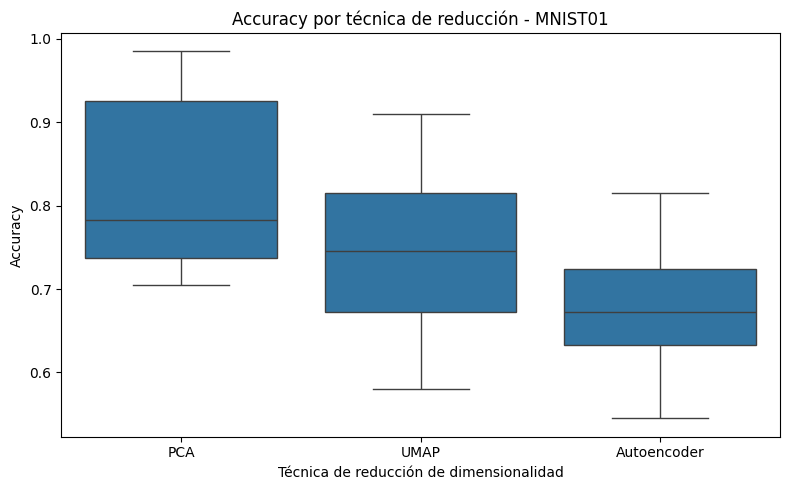

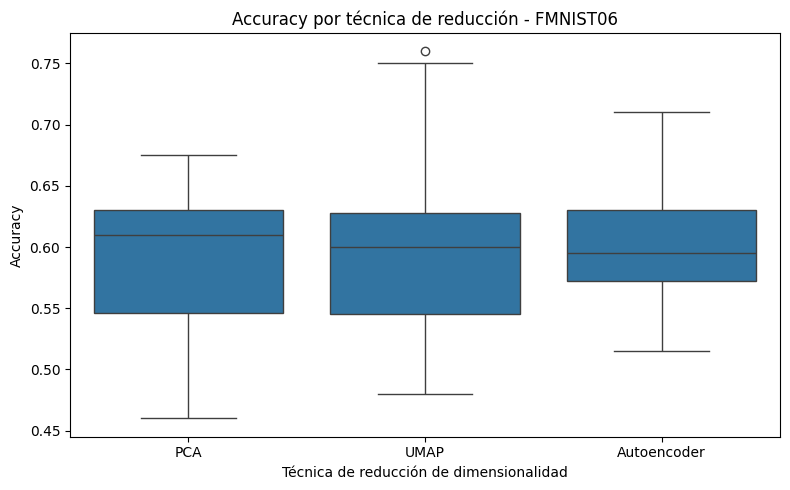

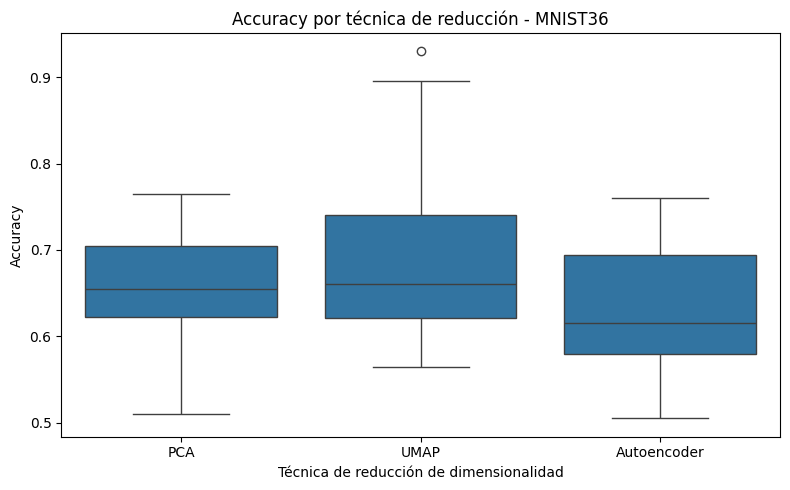

In [ ]:
col_dataset = "Dataset"
col_method = "Reducción"
col_metric = "Accuracy"

# opcional: limitar a ciertas técnicas
methods_to_plot = None  

# tamaño del gráfico
figsize = (8, 5)

# === PREPROCESADO ===

df_plot = df.copy()

if methods_to_plot is not None:
    df_plot = df_plot[df_plot[col_method].isin(methods_to_plot)]


datasets = df_plot[col_dataset].unique()

for dataset in datasets:
    data_subset = df_plot[df_plot[col_dataset] == dataset]

    plt.figure(figsize=figsize)
    order = (
        data_subset
        .groupby(col_method)[col_metric]
        .mean()
        .sort_values(ascending=False)
        .index
    )
    order = (
        "PCA",
        "UMAP",
        "Autoencoder"
    )
    sns.boxplot(
        data=data_subset,
        x=col_method,
        y=col_metric,
        order=order
    )

    plt.title(f"{col_metric} por técnica de reducción - {dataset}")
    plt.xlabel("Técnica de reducción de dimensionalidad")
    plt.ylabel(col_metric)

    plt.tight_layout()
    plt.show()

#### Añadir cúbits a los boxplot por reducción

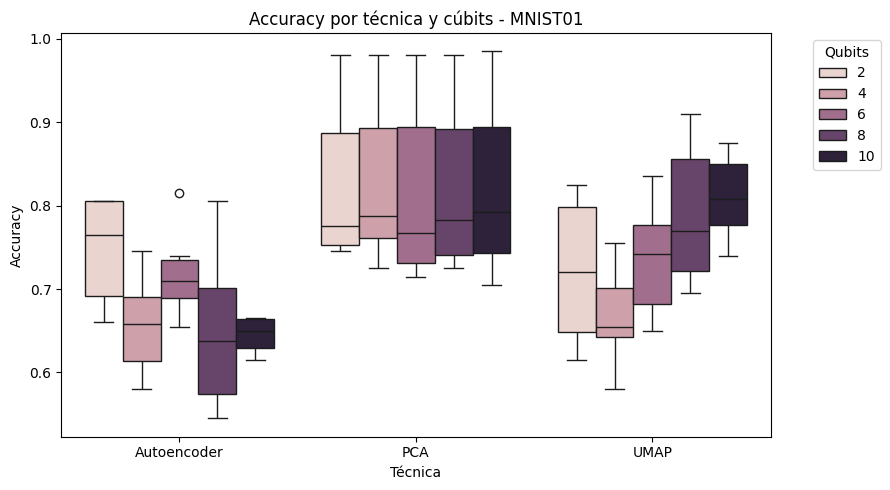

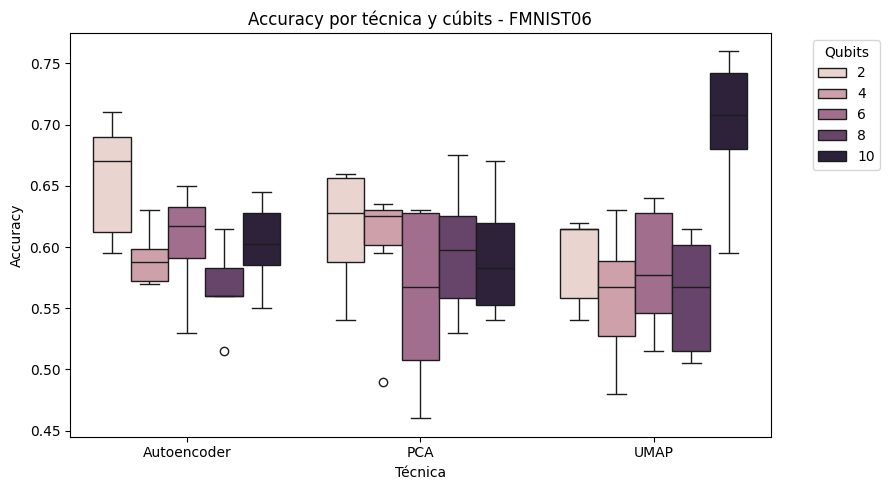

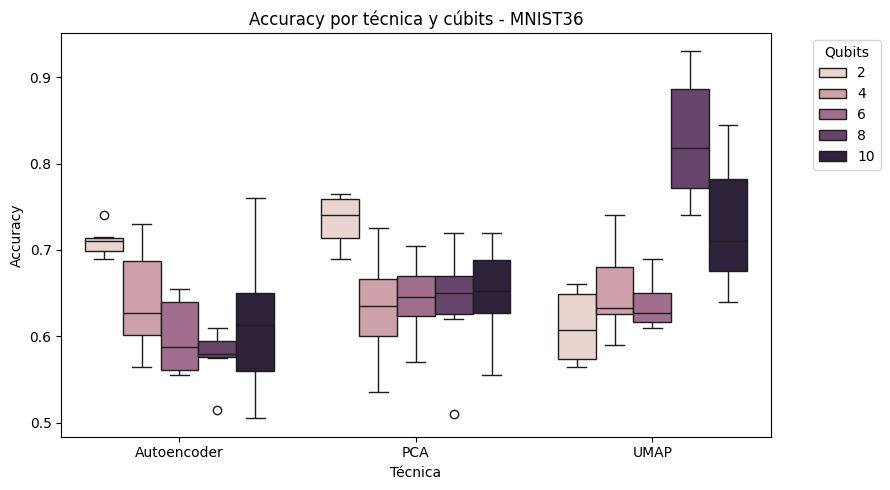

In [ ]:
# === CONFIGURACIÓN ===
col_qubits = "Qubits"

figsize = (9, 5)

datasets = df[col_dataset].unique()

for dataset in datasets:
    data_subset = df[df[col_dataset] == dataset]

    plt.figure(figsize=figsize)

    sns.boxplot(
        data=data_subset,
        x=col_method,
        y=col_metric,
        hue=col_qubits
    )

    plt.title(f"{col_metric} por técnica y cúbits - {dataset}")
    plt.xlabel("Técnica")
    plt.ylabel(col_metric)

    plt.legend(title="Qubits", bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

## Efecto de config FM: heat map

In [7]:
df['FeatureMap'] = df['FeatureMap'].replace('pauli', 'z')

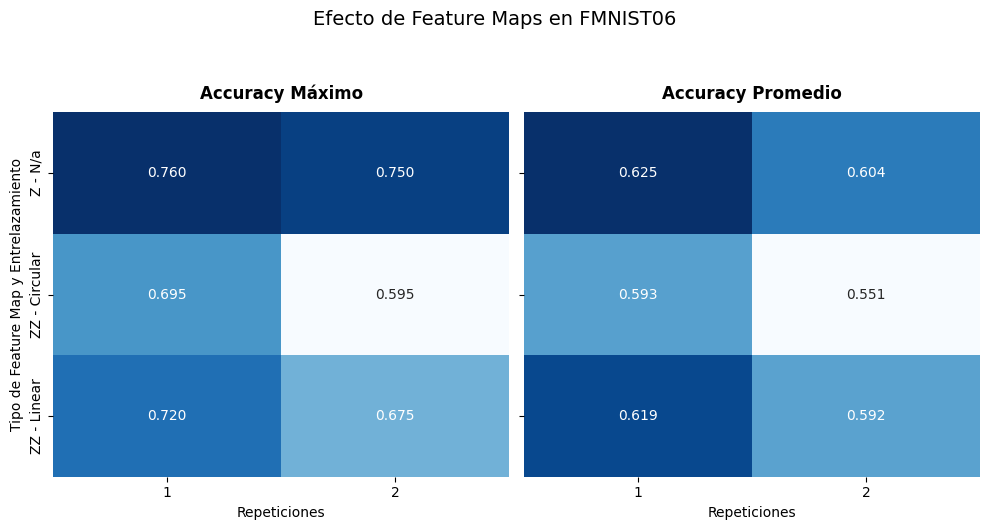

In [ ]:
DATASET_ELEGIDO = 'FMNIST06' 
df['Config_Y'] = df['FeatureMap'].str.upper() + ' - ' + df['FM Entanglement'].str.capitalize()
# Filtrar los datos exclusivamente para el dataset seleccionado
df_subset = df[df['Dataset'] == DATASET_ELEGIDO].copy()

#Crear las matrices pivotadas: una para MAX y otra para MEAN
matriz_max = pd.pivot_table(
    df_subset, 
    values='Accuracy', 
    index='Config_Y', 
    columns='FM Reps', 
    aggfunc='max'
)

matriz_mean = pd.pivot_table(
    df_subset, 
    values='Accuracy', 
    index='Config_Y', 
    columns='FM Reps', 
    aggfunc='mean'
)

#Crear la figura con 2 subgráficos (1 fila, 2 columnas) compartiendo el eje Y
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

#Dibujar el Heatmap del Rendimiento MÁXIMO
sns.heatmap(
    matriz_max, 
    annot=True, 
    fmt='.3f', 
    cmap='Blues', 
    cbar=False,
    ax=axes[0]
)
axes[0].set_title('Accuracy Máximo', pad=10, fontweight='bold')
axes[0].set_xlabel('Repeticiones')
axes[0].set_ylabel('Tipo de Feature Map y Entrelazamiento')

#Dibujar el Heatmap del Rendimiento PROMEDIO
sns.heatmap(
    matriz_mean, 
    annot=True, 
    fmt='.3f', 
    cmap='Blues', 
    cbar=False,
    cbar_kws={'label': 'Accuracy'},
    ax=axes[1]
)
axes[1].set_title('Accuracy Promedio', pad=10, fontweight='bold')
axes[1].set_xlabel('Repeticiones')
axes[1].set_ylabel('')

plt.suptitle(f'Efecto de Feature Maps en {DATASET_ELEGIDO}', y=1.05, fontsize=14)
plt.tight_layout()

plt.show()

# Análisis Amplitude

In [ ]:
import pandas as pd
df_amplitude = pd.read_excel("./resumen_Amplitude_final.xlsx")
def clasificar_ablacion(etiqueta):
    etiqueta = str(etiqueta).upper()
    
    # Base: RealAmplitudes, 2 reps, Linear
    if 'RA2L' in etiqueta or 'RA2LINEAR' in etiqueta:
        return 'Base'
    # Modificación 1: Cambio a SU2 (mantiene 2 reps y Linear)
    elif 'SU22L' in etiqueta or 'SU22LINEAR' in etiqueta:
        return '+ SU2'
    # Modificación 2: Cambio a Full Entanglement (mantiene RA y 2 reps)
    elif 'RA2FULL' in etiqueta:
        return '+ Full Ent.'
    # Modificación 3: Aumento a 3 Repeticiones (mantiene RA y Linear)
    elif 'RA3L' in etiqueta or 'RA3LINEAR' in etiqueta:
        return '+ 3 Reps'
    else:
        return 'Config. Extra' # Por si tienes pruebas adicionales que no entran en la ablación

# 2. Aplicar el mapeo para crear una nueva columna
df_amplitude['Config_Ablacion'] = df_amplitude['Ansatz'].apply(clasificar_ablacion)

df_amplitude

,Dataset,Reducción,Ansatz,Qubits,Accuracy,precision,recall,F1,Time,TN,FP,FN,TP,Depth_Ansatz,Params_Ansatz,reps,Config_Ablacion
0,FMNIST06,Amplitude,RA2Full,1024,0.730,0.730000,0.73,0.730000,3:47:16,73,27,27,73,30,30,2,+ Full Ent.
1,MNIST01,Amplitude,RA2Full,1024,0.955,0.917431,1.00,0.956938,3:45:50,91,9,0,100,30,30,2,+ Full Ent.
2,MNIST36,Amplitude,RA2Full,1024,0.945,0.978495,0.91,0.943005,3:41:03,98,2,9,91,30,30,2,+ Full Ent.
3,FMNIST06,Amplitude,RA2L,1024,0.625,0.765957,0.36,0.489796,3:46:01,89,11,64,36,14,30,2,Base
4,MNIST01,Amplitude,RA2L,1024,0.705,0.976744,0.42,0.587413,3:38:16,99,1,58,42,14,30,2,Base
5,MNIST36,Amplitude,RA2L,1024,0.610,0.761905,0.32,0.450704,4:03:51,90,10,68,32,14,30,2,Base
6,FMNIST06,Amplitude,RA3Linear,1024,0.730,0.773810,0.65,0.706522,3:43:38,81,19,35,65,17,40,3,+ 3 Reps
7,MNIST01,Amplitude,RA3Linear,1024,0.745,0.945455,0.52,0.670968,3:42:38,97,3,48,52,17,40,3,+ 3 Reps
8,MNIST36,Amplitude,RA3Linear,1024,0.520,0.833333,0.05,0.094340,3:42:10,99,1,95,5,17,40,3,+ 3 Reps
9,FMNIST06,Amplitude,SU22L,1024,0.660,0.833333,0.40,0.540541,3:31:22,92,8,60,40,17,60,2,+ SU2


C:\Users\pablo\AppData\Local\Temp\ipykernel_25552\837230011.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nuevas_etiquetas)


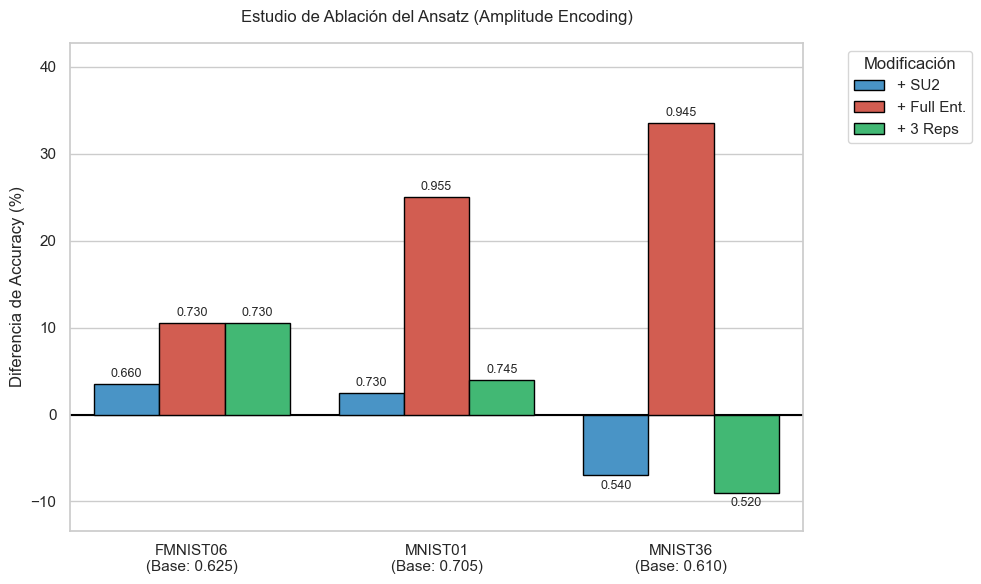

In [25]:
def clasificar_ablacion(etiqueta):
    etiqueta = str(etiqueta).upper()
    if 'RA2L' in etiqueta or 'RA2LINEAR' in etiqueta: return 'Base'
    elif 'SU22L' in etiqueta or 'SU22LINEAR' in etiqueta: return '+ SU2'
    elif 'RA2FULL' in etiqueta: return '+ Full Ent.'
    elif 'RA3L' in etiqueta or 'RA3LINEAR' in etiqueta: return '+ 3 Reps'
    else: return 'Otro'

df_amplitude['Config_Ablacion'] = df_amplitude['Ansatz'].apply(clasificar_ablacion)

# Descartamos las configuraciones que no sean del estudio de ablación
df_ablacion = df_amplitude[df_amplitude['Config_Ablacion'] != 'Otro'].copy()

# 2. Extraer el Accuracy de la configuración Base para cada Dataset
base_accuracies = df_ablacion[df_ablacion['Config_Ablacion'] == 'Base'].set_index('Dataset')['Accuracy'].to_dict()

# Mapear ese Accuracy base de vuelta a todas las filas según su dataset
df_ablacion['Accuracy_Base'] = df_ablacion['Dataset'].map(base_accuracies)

# 3. Filtrar el dataframe para quedarnos solo con las modificaciones (la base será nuestro eje 0)
df_mods = df_ablacion[df_ablacion['Config_Ablacion'] != 'Base'].copy()

# Calcular la diferencia porcentual
df_mods['Diff_Porcentual'] = ((df_mods['Accuracy'] - df_mods['Accuracy_Base'])) * 100

# 4. Configuración visual del gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Forzamos una línea negra fuerte en el cero (nuestra Base)
plt.axhline(0, color='black', linewidth=1.5, zorder=1)

paleta_mods = {
    '+ SU2': '#3498db',        
    '+ Full Ent.': '#e74c3c',  
    '+ 3 Reps': '#2ecc71'      
}
orden_mods = ['+ SU2', '+ Full Ent.', '+ 3 Reps']

ax = sns.barplot(
    data=df_mods, 
    x='Dataset', 
    y='Diff_Porcentual', 
    hue='Config_Ablacion', 
    hue_order=orden_mods,
    palette=paleta_mods,
    edgecolor='black',
    zorder=2
)

# 5. Añadir las etiquetas del Accuracy absoluto a cada barra
datasets_ordenados = [t.get_text() for t in ax.get_xticklabels()]

# ax.containers almacena los grupos de barras (un contenedor por cada "hue")
for i, container in enumerate(ax.containers):
    mod_actual = orden_mods[i]
    labels = []
    
    for j, patch in enumerate(container.patches):
        dataset_nombre = datasets_ordenados[j]
        
        # Buscar el valor absoluto original en el dataframe
        fila = df_mods[(df_mods['Dataset'] == dataset_nombre) & (df_mods['Config_Ablacion'] == mod_actual)]
        
        if not fila.empty and not pd.isna(patch.get_height()):
            valor_absoluto = fila['Accuracy'].values[0]
            labels.append(f"{valor_absoluto:.3f}")
        else:
            labels.append("")
    
    # Colocar la etiqueta en la barra. 
    # padding=3 separa el texto ligeramente del borde de la barra.
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

# 6. Modificar el eje X para mostrar el Accuracy Base debajo del nombre del dataset
nuevas_etiquetas = []
for ds in datasets_ordenados:
    b_acc = base_accuracies.get(ds, 0)
    nuevas_etiquetas.append(f"{ds}\n(Base: {b_acc:.3f})")
    
ax.set_xticklabels(nuevas_etiquetas)

# 7. Ajustes finales de formato
plt.title('Estudio de Ablación del Ansatz (Amplitude Encoding)', pad=15)
plt.ylabel('Diferencia de Accuracy (%)')
plt.xlabel('') 
plt.legend(title='Modificación', bbox_to_anchor=(1.05, 1), loc='upper left')

# Ampliamos ligeramente el límite Y para que las etiquetas absolutas no se corten
ymin, ymax = plt.ylim()
plt.ylim(ymin * 1.2, ymax * 1.2)

plt.tight_layout()
plt.show()

In [14]:
columnas_amp = ['Dataset', 'Reducción', 'Qubits', 'Accuracy', 'Time', 'Config_Ablacion']
df_amp_limpio = df_amplitude[columnas_amp].copy()
df_amp_limpio['Qubits'] = 10
# Añadimos la etiqueta identificativa
df_amp_limpio['Tipo_Encoding'] = 'Amplitude'

# 2. Procesar el DataFrame de Angle Encoding
# Para Angle no necesitamos las características del Ansatz o Feature Map en esta vista global
columnas_ang = ['Dataset', 'Reducción', 'Qubits', 'Accuracy', 'Time']
df_ang_limpio = df[columnas_ang].copy()

# Añadimos la etiqueta identificativa
df_ang_limpio['Tipo_Encoding'] = 'Angle'
# Como Angle no tiene 'Config_Ablacion', creamos la columna con un valor nulo/neutro 
# para que los dataframes encajen perfectamente al unirlos
df_ang_limpio['Config_Ablacion'] = 'N/A'


# 3. Unificar ambos DataFrames
df_global = pd.concat([df_amp_limpio, df_ang_limpio], ignore_index=True)

# 4. (Opcional pero recomendado) Reordenar las columnas para que quede más visual
orden_columnas = [
    'Dataset', 'Tipo_Encoding', 'Reducción', 'Qubits', 
    'Config_Ablacion', 'Accuracy', 'Time'
]
df_global = df_global[orden_columnas]

# Comprobación de la estructura final
print(df_global.sample(5))

      Dataset Tipo_Encoding    Reducción  Qubits Config_Ablacion  Accuracy  \
48    MNIST01         Angle  Autoencoder       6             N/A     0.720   
106  FMNIST06         Angle          PCA      10             N/A     0.545   
163  FMNIST06         Angle         UMAP       4             N/A     0.590   
11    MNIST36     Amplitude    Amplitude      10           + SU2     0.540   
138  FMNIST06         Angle         UMAP       4             N/A     0.585   

        Time  
48   0:05:51  
106  0:20:47  
163  0:03:12  
11   3:38:43  
138  0:03:53  


C:\Users\pablo\AppData\Local\Temp\ipykernel_20448\2857952046.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_limpio = df_filtro.groupby(['Tipo_Encoding', 'Reducción', 'Qubits'], group_keys=False).apply(filtrar_anomalias_iqr)


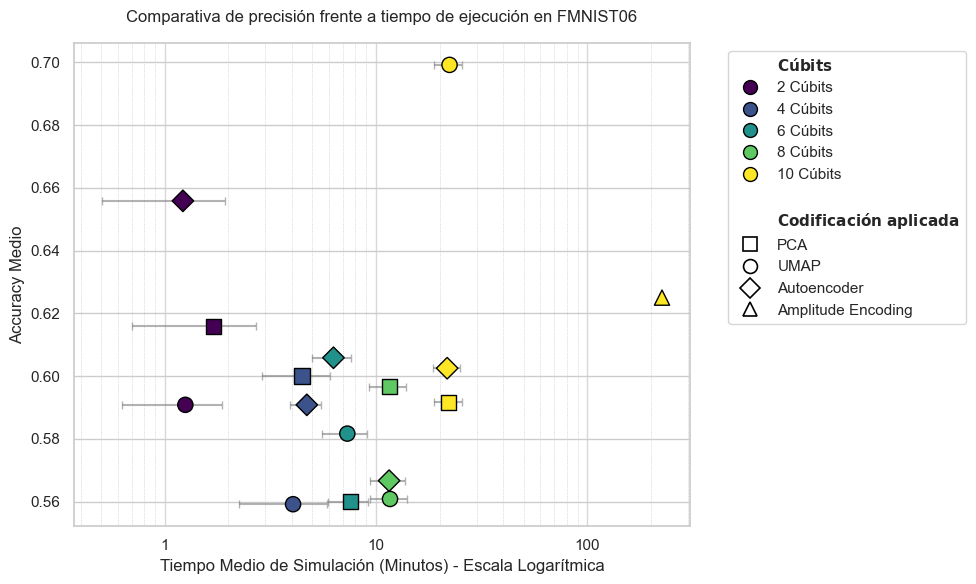

In [19]:
def hms_a_minutos(texto_tiempo):
    try:
        partes = str(texto_tiempo).split(':')
        if len(partes) == 3: return int(partes[0]) * 60 + int(partes[1]) + int(partes[2]) / 60.0
        elif len(partes) == 2: return int(partes[0]) + int(partes[1]) / 60.0
        return 0.0
    except:
        return 0.0

df_global['Tiempo_Min'] = df_global['Time'].apply(hms_a_minutos)

# 2. Selección del Dataset y Filtrado Estricto (Angle + Amplitude Base)
DATASET = 'FMNIST06' # Recuerda generar uno para cada dataset
df_dataset = df_global[df_global['Dataset'] == DATASET].copy()

# Filtramos: Queremos todo lo que sea 'Angle', pero SOLO el 'Base' de 'Amplitude'
# (Asumimos que para Angle la columna Config_Ablacion no aplica o tiene otro valor)
filtro_angle = df_dataset['Tipo_Encoding'].str.upper() == 'ANGLE'
filtro_amp_base = (df_dataset['Tipo_Encoding'].str.upper() == 'AMPLITUDE') & (df_dataset['Config_Ablacion'] == 'Base')

df_filtro = df_dataset[filtro_angle | filtro_amp_base].copy()

df_filtro.loc[filtro_amp_base, 'Reducción'] = 'Amplitude Encoding'

def filtrar_anomalias_iqr(grupo, col='Tiempo_Min'):
    # Si hay menos de 4 muestras en la configuración, no podemos hacer estadística fiable, se queda como está
    if len(grupo) < 4:
        return grupo
    
    Q1 = grupo[col].quantile(0.25)
    Q3 = grupo[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Multiplicador 2.5 (Estricto): Solo elimina puntos exageradamente alejados, 
    # perdonando aquellos que simplemente tardaron un par de épocas más.
    limite_inferior = Q1 - 2.5 * IQR
    limite_superior = Q3 + 2.5 * IQR
    
    return grupo[(grupo[col] >= limite_inferior) & (grupo[col] <= limite_superior)]

df_limpio = df_filtro.groupby(['Tipo_Encoding', 'Reducción', 'Qubits'], group_keys=False).apply(filtrar_anomalias_iqr)

# 3. Agrupación para Medias y Varianza (Solo calculamos Std para el Tiempo)
columnas_agrupacion = ['Tipo_Encoding', 'Reducción', 'Qubits']

df_stats = df_limpio.groupby(columnas_agrupacion).agg(
    Acc_Mean=('Accuracy', 'mean'),
    Time_Mean=('Tiempo_Min', 'mean'),
    Time_Std=('Tiempo_Min', 'std') # Solo nos interesa la varianza del tiempo
).reset_index()

df_stats['Time_Std'] = df_stats['Time_Std'].fillna(0) # Por si hay configuraciones de 1 sola prueba

# 4. Configuración del Lienzo
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

marcadores = {'Angle': 'o', 'Amplitude': '^'}
marcadores = {
    'PCA': 's',                          # Cuadrado
    'UMAP': 'o',                         # Círculo
    'Autoencoder': 'D',                  # Diamante
    'Amplitude Encoding': '^'     # Triángulo (Destaca el caso base de Amplitude)
}

# 5. Dibujar las Barras de Error SOLO en el Eje X (Tiempo)
for _, fila in df_stats.iterrows():
    # Evitamos dibujar barras si el Std es 0 para que quede limpio
    if fila['Time_Std'] > 0:
        plt.errorbar(
            x=fila['Time_Mean'], 
            y=fila['Acc_Mean'], 
            xerr=fila['Time_Std'], # Solo X
            yerr=None,             # Eliminamos Y
            fmt='none',       
            ecolor='gray',    
            elinewidth=1.5,   
            capsize=3,        
            alpha=0.6,        
            zorder=1
        )
# =============================================================================
# 6. Dibujar los Puntos Principales
# =============================================================================
ax = sns.scatterplot(
    data=df_stats,
    x='Time_Mean',
    y='Acc_Mean',
    hue='Qubits',           
    palette='viridis',      
    style='Reducción',  
    markers=marcadores,
    s=120,                  
    edgecolor='black',
    linewidth=1,
    zorder=2,
    legend=False  # Desactivamos la leyenda automática para construirla a mano de forma limpia
)

# =============================================================================
# 7. Escala Logarítmica y Formateo (Se mantiene igual)
# =============================================================================
ax.set_xscale('log')

formatter = ScalarFormatter()
formatter.set_scientific(False)
ax.xaxis.set_major_formatter(formatter)
ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)))
ax.grid(True, which='major', axis='x', linewidth=1, linestyle='-', color='gray', alpha=0.3)
ax.grid(True, which='minor', axis='x', linewidth=0.5, linestyle=':', color='gray', alpha=0.5)

# =============================================================================
# 8. Ajustes visuales finales y CONSTRUCCIÓN DE LEYENDA PERSONALIZADA
# =============================================================================
plt.title(f'Comparativa de precisión frente a tiempo de ejecución en {DATASET}', pad=15)
plt.xlabel('Tiempo Medio de Simulación (Minutos) - Escala Logarítmica')
plt.ylabel('Accuracy Medio')

# --- CONSTRUCCIÓN MANUAl DE LA LEYENDA ---
from matplotlib.lines import Line2D

handles_leyenda = []

# Seccion 1: Cúbits (Codificados solo por COLOR usando una forma neutra de círculo)
handles_leyenda.append(Line2D([0], [0], color='none', label=r'$\bf{Cúbits}$')) # Título de sección

# Obtenemos los cúbits únicos ordenados y extraemos sus colores correspondientes de la paleta
qubits_unicos = sorted(df_stats['Qubits'].unique())
norm = plt.Normalize(vmin=min(qubits_unicos), vmax=max(qubits_unicos))
cmap = plt.get_cmap('viridis')

for q in qubits_unicos:
    color_qubit = cmap(norm(q))
    handles_leyenda.append(Line2D(
        [0], [0], 
        marker='o',              # Forma completamente neutra (círculo)
        color='none', 
        markerfacecolor=color_qubit, 
        markeredgecolor='black', # Borde sutil para que contraste si hay fondos claros
        markersize=10, 
        label=f'{q} Cúbits'
    ))

# Espacio separador entre secciones de la leyenda
handles_leyenda.append(Line2D([0], [0], color='none', label='')) 

# Sección 2: Técnicas de Reducción (Codificadas solo por FORMA en color blanco)
handles_leyenda.append(Line2D([0], [0], color='none', label=r'$\bf{Codificación\ aplicada}$')) # Título de sección

for tecnica, m in marcadores.items():
    if tecnica in df_stats['Reducción'].values: # Solo añade las que existan en el dataset actual
        handles_leyenda.append(Line2D(
            [0], [0], 
            marker=m, 
            color='none', 
            markerfacecolor='white', # Fondo blanco para que no tenga color asociado
            markeredgecolor='black', 
            markeredgewidth=1.2,
            markersize=10, 
            label=tecnica
        ))

# Dibujar la leyenda final aplicando los handles personalizados
plt.legend(handles=handles_leyenda, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
# plt.savefig(f'scatter_tiempo_{DATASET}.pdf', bbox_inches='tight', dpi=300)
plt.show()

In [10]:
df_stats

,Tipo_Encoding,Reducción,Qubits,Acc_Mean,Time_Mean,Time_Std
0,Amplitude,Amplitude,10,0.610000,243.850000,0.000000
1,Angle,Autoencoder,2,0.710000,1.204167,0.343852
2,Angle,Autoencoder,4,0.579375,4.468750,1.302453
3,Angle,Autoencoder,6,0.600625,15.758333,23.249550
4,Angle,Autoencoder,8,0.575000,15.443750,3.096246
5,Angle,Autoencoder,10,0.558750,27.841667,6.685776
6,Angle,PCA,2,0.740000,0.814583,0.144320
7,Angle,PCA,4,0.583125,5.912500,0.868165
8,Angle,PCA,6,0.594375,15.637500,20.415141
9,Angle,PCA,8,0.569375,14.775000,4.796998


# fin

# Otras visualizaciones probadas pero no seleccionadas finalmente

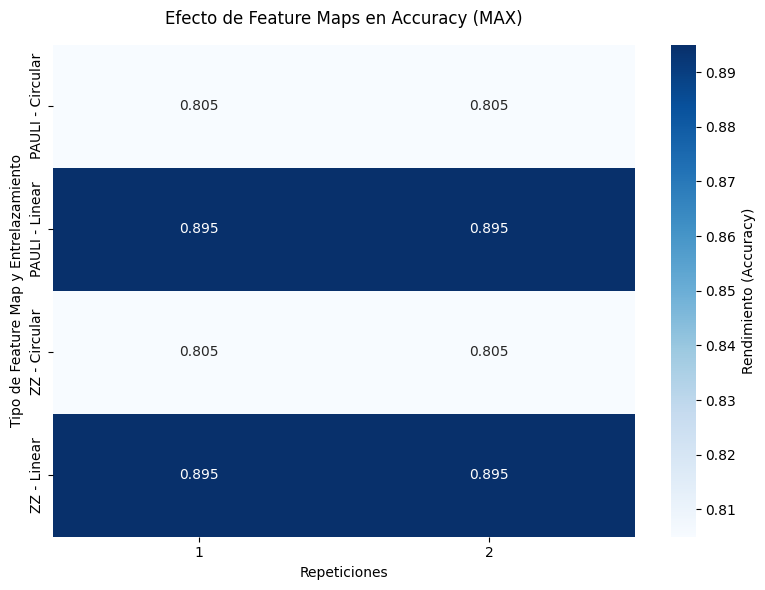

In [4]:
df['Config_Y'] = df['FeatureMap'].str.upper() + ' - ' + df['FM Entanglement'].str.capitalize()

matriz_hm = pd.pivot_table(
    df, 
    values='Accuracy', # Puedes cambiarlo a 'F1'
    index='Config_Y', 
    columns='FM Reps', 
    aggfunc='max'
)

# 4. Dibujar el Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_hm, 
    annot=True, 
    fmt='.3f', 
    cmap='Blues', 
    cbar_kws={'label': 'Rendimiento (Accuracy)'}
)

plt.title('Efecto de Feature Maps en Accuracy (MAX)', pad=15)
plt.ylabel('Tipo de Feature Map y Entrelazamiento')
plt.xlabel('Repeticiones')
plt.tight_layout()

plt.show()

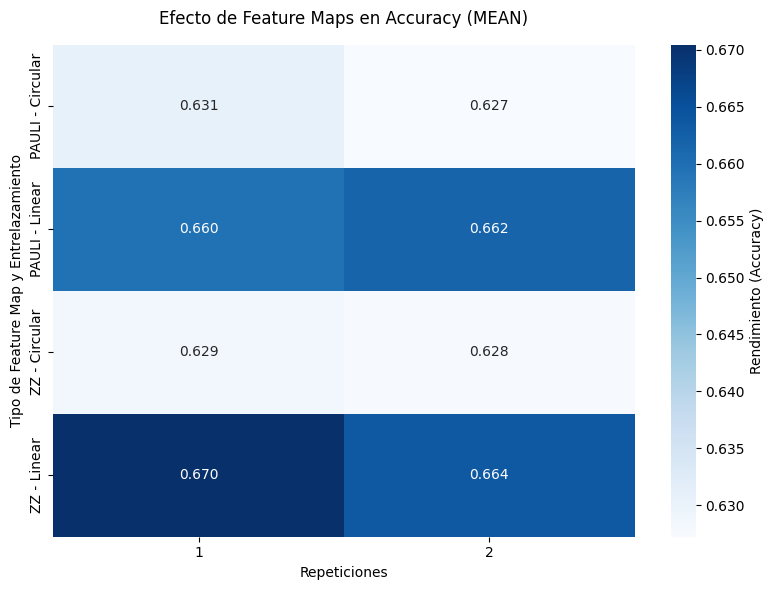

In [14]:
matriz_hm = pd.pivot_table(
    df, 
    values='Accuracy', # Puedes cambiarlo a 'F1'
    index='Config_Y', 
    columns='FM Reps', 
    aggfunc='mean'
)

# 4. Dibujar el Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_hm, 
    annot=True, 
    fmt='.3f', 
    cmap='Blues', 
    cbar_kws={'label': 'Rendimiento (Accuracy)'}
)

plt.title('Efecto de Feature Maps en Accuracy (MEAN)', pad=15)
plt.ylabel('Tipo de Feature Map y Entrelazamiento')
plt.xlabel('Repeticiones')
plt.tight_layout()

plt.show()

In [9]:
df["fm_config"] = df["FM Entanglement"] + "_" + df["FM Reps"].astype(str)

In [10]:
df

,Dataset,Reducción,Qubits,FeatureMap,FM Reps,FM Entanglement,Accuracy,precision,recall,F1,Time,TN,FP,FN,TP,Depth_FM,Depth_Ansatz,Params_Ansatz,fm_config
0,FMNIST06,Autoencoder,10,pauli,1,linear,0.585,0.604938,0.49,0.541436,0:25:31,68,32,51,49,37,14,30,linear_1
1,FMNIST06,Autoencoder,10,pauli,2,linear,0.545,0.571429,0.36,0.441718,0:25:21,73,27,64,36,37,14,30,linear_2
2,FMNIST06,Autoencoder,10,pauli,1,circular,0.545,0.563380,0.40,0.467836,0:25:38,69,31,60,40,64,14,30,circular_1
3,FMNIST06,Autoencoder,10,pauli,2,circular,0.545,0.563380,0.40,0.467836,0:25:46,69,31,60,40,64,14,30,circular_2
4,MNIST01,Autoencoder,10,pauli,1,linear,0.635,0.611570,0.74,0.669683,0:25:17,53,47,26,74,37,14,30,linear_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,MNIST36,UMAP,2,zz,2,circular,0.565,0.555556,0.65,0.599078,0:02:05,48,52,35,65,10,5,6,circular_2
356,MNIST36,UMAP,4,zz,2,circular,0.695,0.760000,0.57,0.651429,0:06:21,82,18,43,57,28,8,12,circular_2
357,MNIST36,UMAP,6,zz,2,circular,0.635,0.648352,0.59,0.617801,0:07:02,68,32,41,59,40,10,18,circular_2
358,MNIST36,UMAP,8,zz,2,circular,0.740,0.961538,0.50,0.657895,0:14:20,98,2,50,50,52,12,24,circular_2


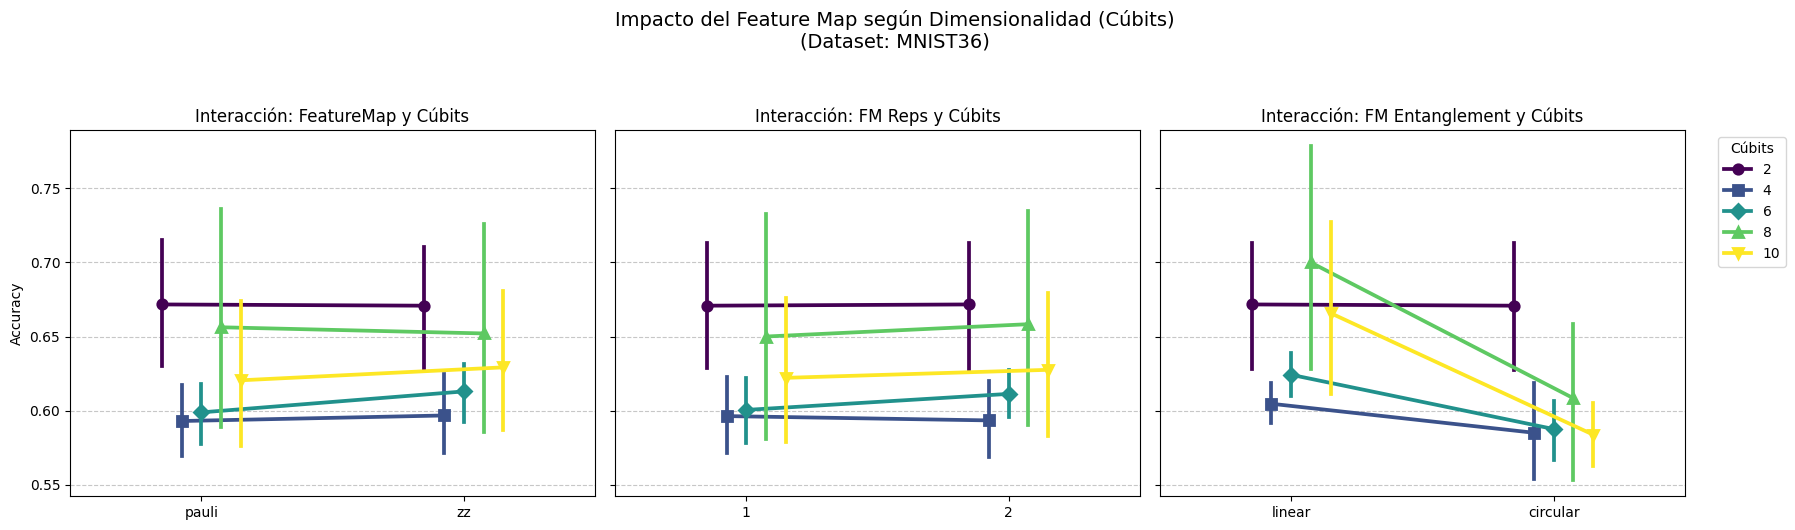

In [31]:
plotear_interaccion_fm_cubits(df,"MNIST36")

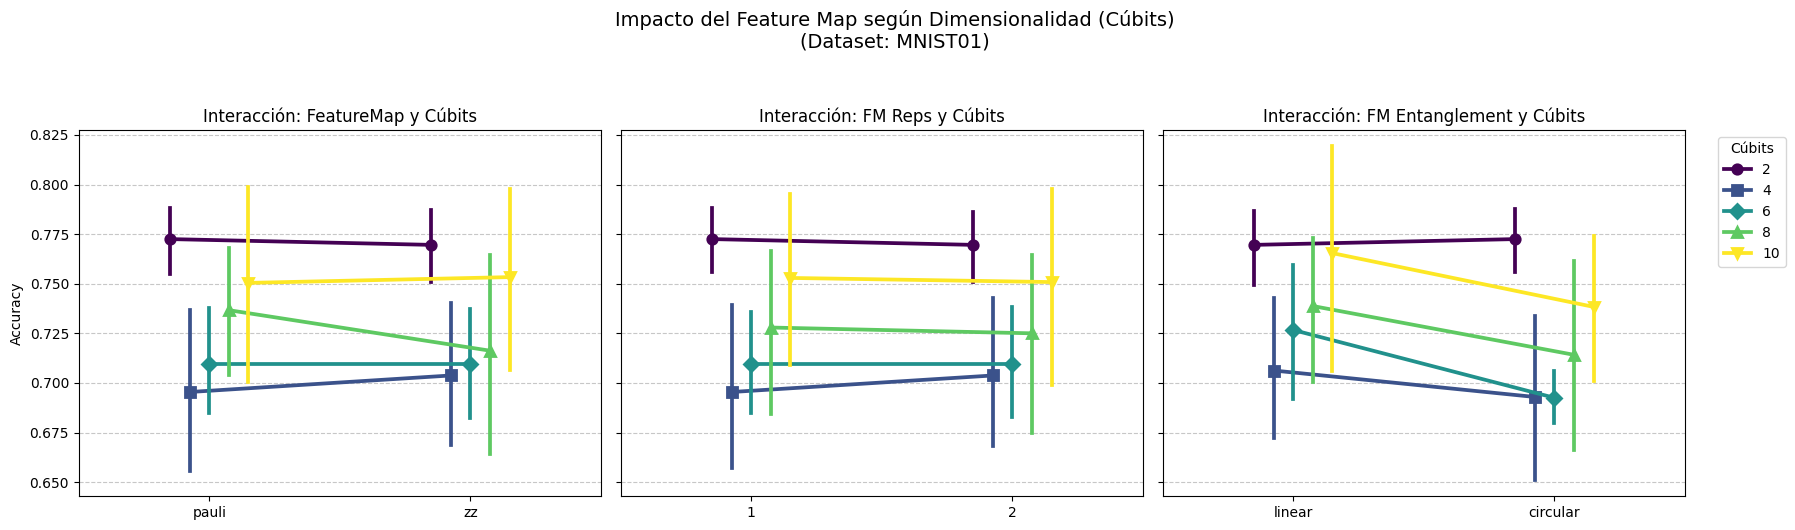

In [32]:
plotear_interaccion_fm_cubits(df,"MNIST01")

## Pareto

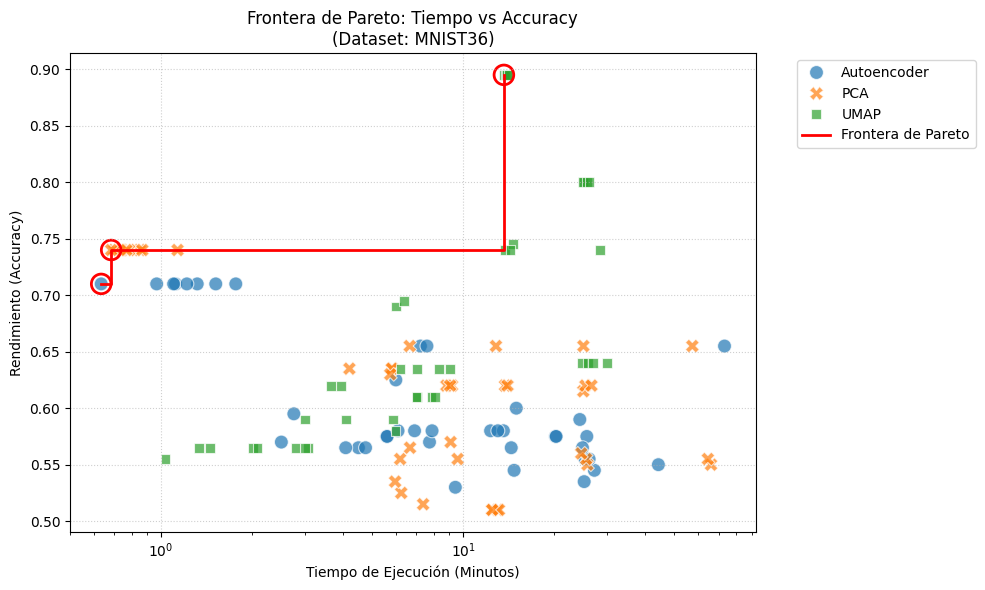

In [ ]:
def calcular_frontera_pareto(xs, ys, max_x=False, max_y=True):
    """
    Calcula los índices de los puntos que forman la frontera de Pareto.
    Por defecto, minimizamos X (coste) y maximizamos Y (rendimiento).
    """
    puntos = np.column_stack((xs, ys))
    es_pareto = np.ones(puntos.shape[0], dtype=bool)
    
    for i, c in enumerate(puntos):
        # Ajustamos los signos dependiendo de si maximizamos o minimizamos
        x_cond = puntos[:, 0] >= c[0] if max_x else puntos[:, 0] <= c[0]
        y_cond = puntos[:, 1] >= c[1] if max_y else puntos[:, 1] <= c[1]
        
        # Una configuración domina a otra si es estrictamente mejor o igual en todo, 
        # y estrictamente mejor en al menos una métrica.
        dominado = np.any((x_cond & y_cond) & ((puntos[:, 0] != c[0]) | (puntos[:, 1] != c[1])))
        if dominado:
            es_pareto[i] = False
            
    return es_pareto

def plotear_pareto_corregido(dataframe, dataset_objetivo):
    """
    Dibuja la Frontera de Pareto usando el tiempo en minutos como coste.
    """
    df_filtrado = dataframe[dataframe[COL_DATASET] == dataset_objetivo].copy()
    
    # IMPORTANTE: Eliminar filas con NaN en tiempo o accuracy para no romper el cálculo
    df_filtrado = df_filtrado.dropna(subset=[COL_COST, COL_METRIC])
    
    xs = df_filtrado[COL_COST].values
    ys = df_filtrado[COL_METRIC].values
    
    mascara_pareto = calcular_frontera_pareto(xs, ys, max_x=False, max_y=True)
    df_filtrado['es_pareto'] = mascara_pareto
    
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(
        data=df_filtrado, x=COL_COST, y=COL_METRIC, 
        hue=COL_REDUCTION, style=COL_REDUCTION, s=100, alpha=0.7
    )
    
    # Trazar la línea de Pareto
    df_pareto = df_filtrado[df_filtrado['es_pareto']].sort_values(by=COL_COST)
    
    # Solo dibujamos la línea si hay más de un punto en la frontera
    if len(df_pareto) > 1:
        # Añadimos un step 'post' para que parezca una frontera escalonada (muy típico en Pareto)
        plt.step(df_pareto[COL_COST], df_pareto[COL_METRIC], where='post', color='red', linestyle='-', linewidth=2, label='Frontera de Pareto')
    else:
        plt.plot(df_pareto[COL_COST], df_pareto[COL_METRIC], color='red', marker='o', label='Frontera de Pareto')
        
    plt.scatter(df_pareto[COL_COST], df_pareto[COL_METRIC], facecolors='none', edgecolors='red', s=200, linewidths=2)
    plt.xscale('log')
    plt.title(f'Frontera de Pareto: Tiempo vs Accuracy\n(Dataset: {dataset_objetivo})')
    plt.xlabel('Tiempo de Ejecución (Minutos)')
    plt.ylabel(f'Rendimiento ({COL_METRIC})')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
plotear_pareto_corregido(df, dataset_objetivo='MNIST36')

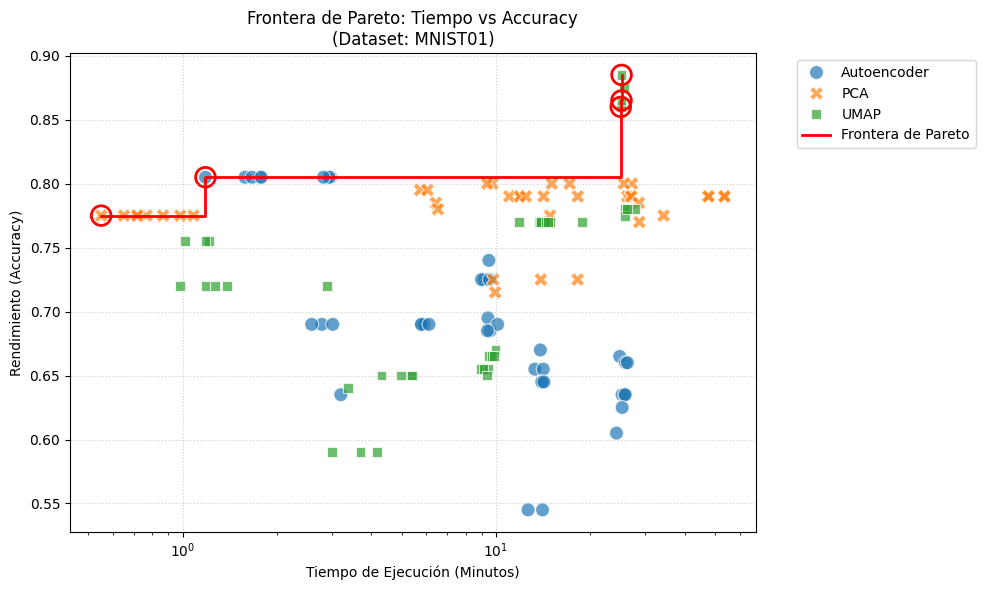

In [23]:
plotear_pareto_corregido(df, dataset_objetivo='MNIST01')

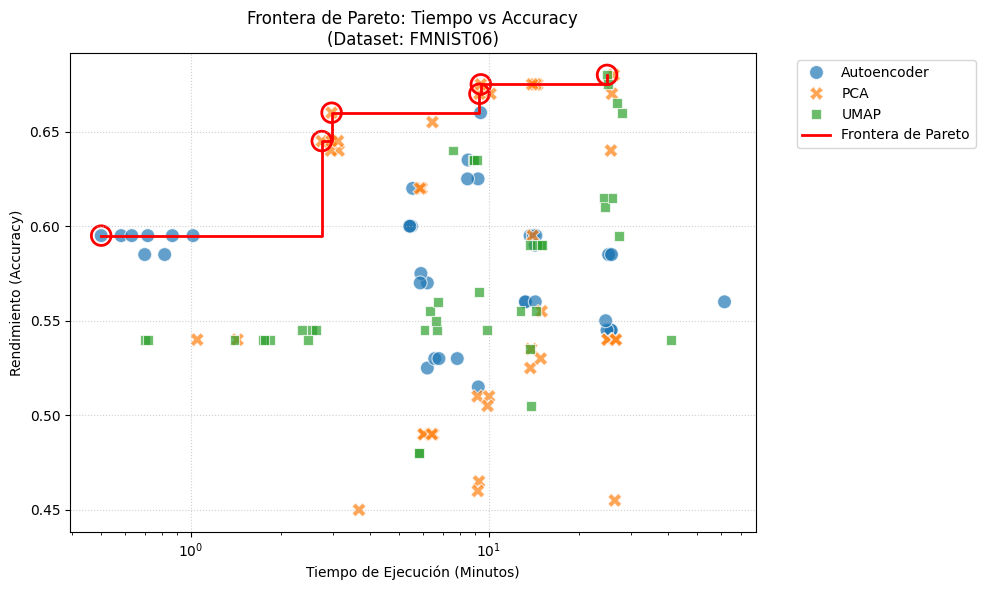

In [24]:
plotear_pareto_corregido(df, dataset_objetivo='FMNIST06')

In [18]:
df_sorted = df.sort_values(by="Time", ascending=False)

top5 = df_sorted.head(5)

print(top5)

      Dataset    Reducción  Qubits FeatureMap  FM Reps FM Entanglement  \
81    MNIST36  Autoencoder       6      pauli        2          linear   
232   MNIST36          PCA       6         zz        1        circular   
239   MNIST36          PCA      10         zz        2        circular   
108  FMNIST06  Autoencoder       8         zz        1          linear   
229   MNIST36          PCA      10         zz        2          linear   

     Accuracy  precision  recall        F1     Time  TN  FP  FN  TP  Depth_FM  \
81      0.655   0.616541    0.82  0.703863  1:13:15  49  51  18  82        25   
232     0.550   0.558140    0.48  0.516129  1:06:05  62  38  52  48        40   
239     0.555   0.551402    0.59  0.570048  1:04:31  52  48  41  59        64   
108     0.560   0.549180    0.67  0.603604  1:01:48  45  55  33  67        31   
229     0.655   0.666667    0.62  0.642487  0:57:19  69  31  38  62        37   

     Depth_Ansatz  Params_Ansatz   fm_config  tiempo_minutos  
81   

### Análisis del efecto del feature map

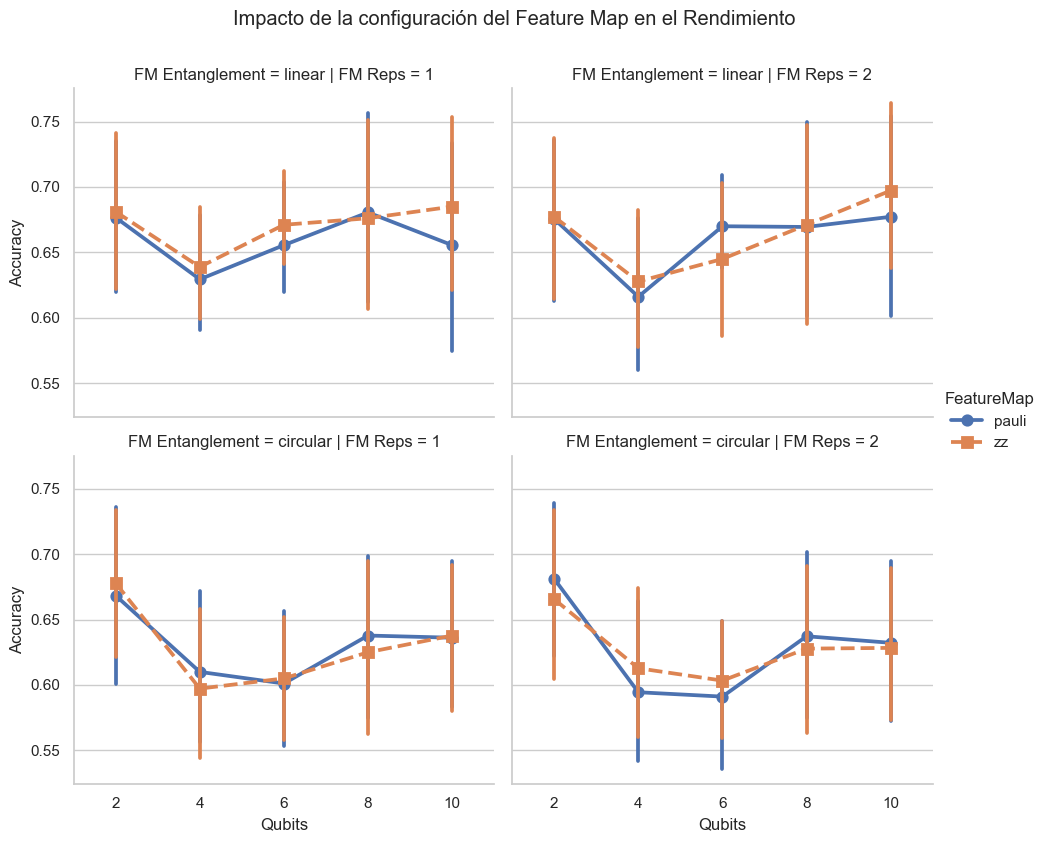

In [6]:
sns.set_theme(style="whitegrid")

# Creamos el FacetGrid usando catplot
g = sns.catplot(
    data=df, 
    x="Qubits", 
    y="Accuracy", 
    hue="FeatureMap", # Diferencia Pauli de ZZ por color
    col="FM Reps",       # Crea dos columnas: Reps 1 y Reps 2
    row="FM Entanglement", # Crea dos filas: Linear y Circular
    kind="point",     # Usa puntos unidos por líneas para ver tendencias
    markers=["o", "s"],
    linestyles=["-", "--"],
    height=4, 
    aspect=1.2
)

g.fig.suptitle('Impacto de la configuración del Feature Map en el Rendimiento', y=1.05)
plt.show()

### Frontera pareto de accuracy y tiempo
Puede ser muy interesante hacer un scater plot tiempo/accuracy y mostrar otras características mediante formas/colores ya que visualmente podrían apreciarse clusters en lo datos

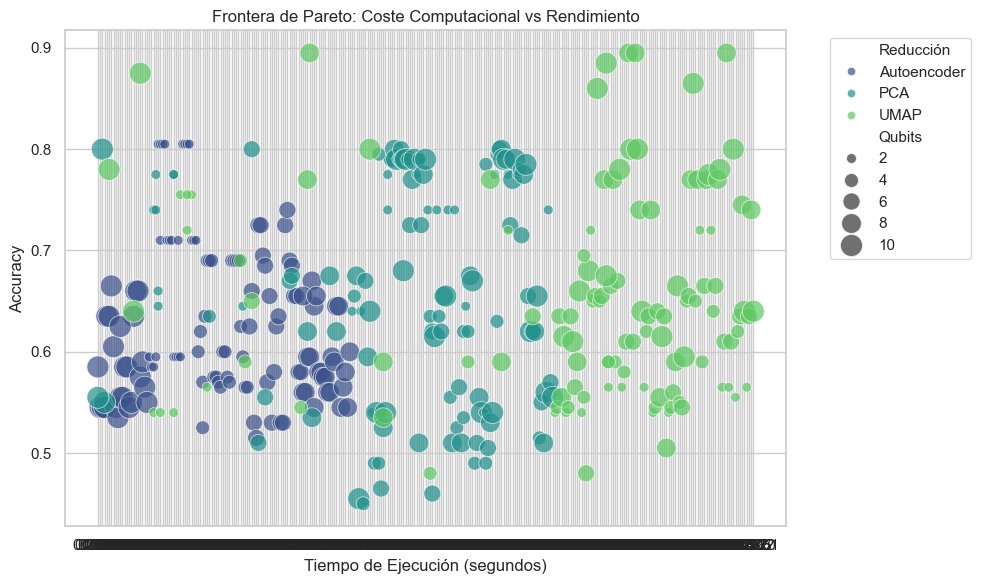

In [9]:
# Opcional: Función para calcular y dibujar la línea de Pareto real
def plot_pareto_frontier(Xs, Ys, maxX=False, maxY=True):
    # Lógica para encontrar los puntos óptimos...
    pass # Puedes omitir la línea geométrica y que sea solo visual

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x="Time", # o "Profundidad_Circuito"
    y="Accuracy", 
    hue="Reducción",      # PCA, UMAP, Autoencoder
    size="Qubits",       # Puntos más grandes = más cúbits
    sizes=(50, 250),     # Rango de tamaños
    alpha=0.7,
    palette="viridis"
)

plt.title('Frontera de Pareto: Coste Computacional vs Rendimiento')
plt.xlabel('Tiempo de Ejecución (segundos)')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Leyenda fuera del gráfico
plt.tight_layout()
plt.show()